# Загрузка данных

In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# fetch dataset 
polish_companies_bankruptcy = fetch_ucirepo(id=365) 
  
# data (as pandas dataframes) 
X = polish_companies_bankruptcy.data.original
X = X[X['year'] == 5].drop(columns='year')
# metadata 
# print(polish_companies_bankruptcy.metadata) 
  
# variable information 
print(polish_companies_bankruptcy.variables) 


     name     role        type demographic description units missing_values
0    year  Feature     Integer        None        None  None             no
1      A1  Feature  Continuous        None        None  None             no
2      A2  Feature  Continuous        None        None  None             no
3      A3  Feature  Continuous        None        None  None             no
4      A4  Feature  Continuous        None        None  None            yes
..    ...      ...         ...         ...         ...   ...            ...
61    A61  Feature  Continuous        None        None  None            yes
62    A62  Feature  Continuous        None        None  None             no
63    A63  Feature  Continuous        None        None  None            yes
64    A64  Feature  Continuous        None        None  None            yes
65  class   Target     Integer        None        None  None             no

[66 rows x 7 columns]


In [110]:
sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="crest",
    font_scale=1.1,
    rc={
        "figure.figsize": (8, 4),
        "figure.dpi": 120,
        "savefig.dpi": 300,

        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.4,

        "axes.facecolor": "white",
        "figure.facecolor": "white",

        "patch.edgecolor": "black",
        "patch.linewidth": 0.8
    }
)

In [111]:
X.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
37495,0.088238,0.55472,0.01134,1.0205,-66.5200,0.342040,0.109490,0.57752,1.0881,0.32036,...,0.080955,0.275430,0.91905,0.002024,7.2711,4.7343,142.760,2.5568,3.2597,0
37496,-0.006202,0.48465,0.23298,1.5998,6.1825,0.000000,-0.006202,1.06340,1.2757,0.51535,...,-0.028591,-0.012035,1.00470,0.152220,6.0911,3.2749,111.140,3.2841,3.3700,0
37497,0.130240,0.22142,0.57751,3.6082,120.0400,0.187640,0.162120,3.05900,1.1415,0.67731,...,0.123960,0.192290,0.87604,0.000000,8.7934,2.9870,71.531,5.1027,5.6188,0
37498,-0.089951,0.88700,0.26927,1.5222,-55.9920,-0.073957,-0.089951,0.12740,1.2754,0.11300,...,0.418840,-0.796020,0.59074,2.878700,7.6524,3.3302,147.560,2.4735,5.9299,0
37499,0.048179,0.55041,0.10765,1.2437,-22.9590,0.000000,0.059280,0.81682,1.5150,0.44959,...,0.240400,0.107160,0.77048,0.139380,10.1180,4.0950,106.430,3.4294,3.3622,0


In [112]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5910 entries, 37495 to 43404
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      5907 non-null   float64
 1   A2      5907 non-null   float64
 2   A3      5907 non-null   float64
 3   A4      5889 non-null   float64
 4   A5      5899 non-null   float64
 5   A6      5907 non-null   float64
 6   A7      5907 non-null   float64
 7   A8      5892 non-null   float64
 8   A9      5909 non-null   float64
 9   A10     5907 non-null   float64
 10  A11     5907 non-null   float64
 11  A12     5889 non-null   float64
 12  A13     5910 non-null   float64
 13  A14     5907 non-null   float64
 14  A15     5904 non-null   float64
 15  A16     5892 non-null   float64
 16  A17     5892 non-null   float64
 17  A18     5907 non-null   float64
 18  A19     5910 non-null   float64
 19  A20     5910 non-null   float64
 20  A21     5807 non-null   float64
 21  A22     5907 non-null   float64
 22  A23   

In [113]:
X['class'].value_counts(normalize=True)

class
0    0.930626
1    0.069374
Name: proportion, dtype: float64

#### Функции

In [114]:
def get_iqr_indexes(data, num_columns, threshold = 1.5):
    drop_indexes = []
    for col in num_columns:
        df = data[col]
        q1 = df.quantile(q=0.25)
        q3 = df.quantile(q=0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - (threshold * iqr)
        upper_bound = q3 + (threshold * iqr)
        
        drop_indexes += list(df[(df < lower_bound) | (df > upper_bound)].index)

    return set(drop_indexes)

In [115]:
# X_hist_num_columns = list(X.columns)

In [116]:
# X_hist_num_columns.pop(-1)

In [117]:
# X_hist = X.drop(index=get_iqr_indexes(X, X_hist_num_columns, threshold = 25))
# print(len(X_hist))

In [118]:
# from sklearn.preprocessing import RobustScaler

# rs = RobustScaler()
# X_scaled = pd.DataFrame(rs.fit_transform(X_hist), columns=X_hist.columns)

In [119]:
# for i in X_hist_num_columns:
#     # plt.hist(X_hist[i], bins=150)
#     # plt.title(i)
#     # plt.show()
#     sns.kdeplot(X_hist[i])

In [120]:
# for i in X_hist_num_columns:
#     sns.kdeplot(X_scaled[i])


In [121]:
X_scaled = X

# Предобработка данных


### Обработка null значений

#### Матрица корреляции

In [122]:
def get_drop_corr_columns(x, missing_info, threshold=0.95):
    corr_matrix = x.corr(method='spearman').abs()
    
    corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            .stack()
            .reset_index(name='Correlation')
    )
    corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

    corr_pairs = corr_pairs.join(missing_values_info['Total_missing_values'], on='Feature_1', rsuffix='_1')
    corr_pairs = corr_pairs.join(missing_values_info['Total_missing_values'], on='Feature_2', rsuffix='_2')

    corr_pairs = corr_pairs[corr_pairs['Correlation'] > threshold]

    to_drop = []

    for _, row in corr_pairs.iterrows():
        if row['Total_missing_values'] > row['Total_missing_values_2']:
            to_drop.append(row['Feature_1'])
        else:
            to_drop.append(row['Feature_2'])
    print(list(set(to_drop)))
    return list(set(to_drop))

In [123]:
missing_values_info = pd.DataFrame(
    data=[X.isnull().sum(), (X.isnull().sum()/ len(X)) * 100], 
    index=['Total_missing_values', 'Percent_missing_values']
    ).T

In [124]:
trad_columns = ['A2', 'A3', 'A4', 'A6', 'A7', 'A8', 'A9']

In [125]:
drop_columns = [i for i in get_drop_corr_columns(X_scaled, missing_values_info, threshold=0.95) if i not in trad_columns]

['A14', 'A32', 'A54', 'A47', 'A8', 'A7', 'A17', 'A11', 'A18', 'A26', 'A52', 'A31', 'A61', 'A63', 'A60', 'A10', 'A23', 'A48']


Для того чтобы улучшить качество предсказаний моделей, сильно коррелирующие признаки с наибольшим числом пропущенных значений будут удалены.

In [126]:
X_dropped_columns = X_scaled.drop(columns=drop_columns) 

#### Для анализа природы появления пропусков стоит посмотреть на содержание пропусков в каждом признаке:

In [127]:
missing_values_info = pd.DataFrame(
    data=[X_dropped_columns.isnull().sum(), (X_dropped_columns.isnull().sum()/ len(X)) * 100], 
    index=['Total_missing_values', 'Percent_missing_values']
    ).T
missing_values_info = missing_values_info.sort_values(by=['Total_missing_values'], ascending=False)
missing_values_info

,Total_missing_values,Percent_missing_values
A37,2548.0,43.113367
A27,391.0,6.615905
A45,268.0,4.534687
A24,135.0,2.284264
A53,107.0,1.810491
A64,107.0,1.810491
A28,107.0,1.810491
A21,103.0,1.742809
A41,84.0,1.421320
A12,21.0,0.355330


##### Функции

In [128]:
def group_isnull_info(x, group_columns, mask_columns, printing_results=True):
    gr = x[group_columns]
    mask = x[mask_columns]
    answer = pd.DataFrame()
    for i in range(len(group_columns)):
        answer[i] = gr.iloc[:, i].isnull() * mask.iloc[:, i].isnull()
    answer.columns = group_columns
    if printing_results:
        print("group * mask info:", answer.sum(), sep='\n')
    return answer

def group_div0_info(x, group_columns, mask_columns, printing_results=True):
    gr = x[group_columns]
    mask = x[mask_columns]
    answer = pd.DataFrame()
    for i in range(len(group_columns)):
        answer[i] = gr.iloc[:, i].isnull() * (mask.iloc[:, i] == 0)
    answer.columns = group_columns
    if printing_results:
        print("group * div0 info:", answer.sum(), sep='\n')
    return answer

def group_div1_info(x, group_columns, mask_columns, printing_results=True):
    gr = x[group_columns]
    mask = x[mask_columns]
    answer = pd.DataFrame()
    for i in range(len(group_columns)):
        answer[i] = gr.iloc[:, i].isnull() * (mask.iloc[:, i] == 1)
    answer.columns = group_columns
    if printing_results:
        print("group * div1 info:", answer.sum(), sep='\n')
    return answer

In [129]:
def get_cat_column(column, answer): 
    new_column = column.notna() + column.isnull() * answer * 1 + column.isnull() * 2
    return new_column
    
def add_cat_columns(x, group, answer):
    for i in group:
        x[i+'_miss_type'] = get_cat_column(x[i], answer[i])
    return x

#### Анализ и обработка *групповых* пропусков


У некоторых фичей совпадает количество пропусков, поэтому можно предположить, что значений нет, так как в формулах происходит деление на нуль или какая-либо компания не предоставила данных для рассчета коэффициента. В зависимости от природы происхождения пропуска, будут выбираться разные стратегии заполнения.
Выделены следующие группы признаков:

In [130]:
for i in sorted(set(missing_values_info.Total_missing_values), reverse=True):
    a = list(missing_values_info[missing_values_info['Total_missing_values'] == i].index)
    if len(a) > 1:
     print(i, *a)

107.0 A53 A64 A28
21.0 A12 A4 A40 A46 A33
18.0 A50 A16 A8 A34
3.0 A51 A35 A6 A7 A22 A3 A1 A57 A36 A2 A38 A25 A29 A59
0.0 A13 A20 A19 A42 A30 A39 A49 A43 A44 A55 A58 A56 A62 class


После удаления групп с количеством пропусков < 100 датасет не будет значительно уменьшен, поэтому смысла от обработки такого малого количества данных нет.

In [131]:
dropping_columns = missing_values_info[missing_values_info['Total_missing_values'] < 100].index
X_dropped = pd.DataFrame(X_dropped_columns.dropna(subset=dropping_columns))
X_dropped.index = range(len(X_dropped))

In [132]:
missing_values_info = pd.DataFrame(
    data=[X_dropped.isnull().sum(), (X_dropped.isnull().sum() / len(X_dropped)) * 100], 
    index=['Total_missing_values', 'Percent_missing_values']
    ).T
missing_values_info = missing_values_info.sort_values(by=['Total_missing_values'], ascending=False)

In [133]:
for i in sorted(set(missing_values_info.Total_missing_values), reverse=True):
    a = list(missing_values_info[missing_values_info['Total_missing_values'] == i].index)
    if len(a) > 1:
     print(i, *a)

93.0 A64 A28 A53
0.0 A1 A9 A2 A4 A3 A6 A7 A8 A5 A22 A20 A19 A16 A13 A15 A12 A29 A34 A35 A36 A38 A39 A30 A33 A25 A42 A41 A40 A44 A46 A49 A50 A43 A51 A55 A57 A56 A58 A59 A62 class


Группа:  A53, A64, A28

- X28	working capital / fixed assets
- X53	equity / fixed assets
- X64	sales / fixed assets

Для проверки деления на 0, нет ни одного признака с fixed assets в числителе, поэтомунельзя ничего сказать о природе происхождения пропусков. Они будут заполнены медианным значением

In [134]:
# gr = ['A53', 'A64', 'A28']
# gr = ['A64']
# mask = ['A29'] * len(gr)
# gr_info = group_isnull_info(X_dropped, gr, mask)
# gr_info = group_div0_info(X_dropped, gr, mask)
# add_cat_columns(X_dropped, gr, gr_info) 
# #X_dropped.A53_miss_type.value_counts()

#### Анализ и обработка *одиночных* фичей

In [135]:
for i in sorted(set(missing_values_info.Total_missing_values), reverse=True):
    a = list(missing_values_info[missing_values_info['Total_missing_values'] == i].index)
    if len(a) == 1:
     print(i, *a)

2479.0 A37
341.0 A27
250.0 A45
128.0 A24
101.0 A21


##### X37 (current assets - inventories) / long-term liabilities

Предположительно, такое большое количество пропусков у A37 связано с делением на 0. У компаний часто правда просто отсутствуют долгосрочные обязательства. Поэтому будет выбрана стратегия заполнения медианой со столбцом пометкой об отсутствии данных.

In [136]:
gr = ['A37']
mask = ['A2']
gr_info = group_isnull_info(X_dropped, gr, mask)
gr_info = group_div0_info(X_dropped, gr, mask)
add_cat_columns(X_dropped, gr, gr_info) 
X_dropped.A37_miss_type.value_counts()

group * mask info:
A37    0
dtype: int64
group * div0 info:
A37    0
dtype: int64


A37_miss_type
1    3324
2    2479
Name: count, dtype: int64

##### X21	sales (n) / sales (n-1)

Не смотря на то, что в A21 тоже присутствует деление на sales, пропуски здесь обоснованы лишь отсутствием данных о предыдущем году. То есть либо данных просто нет, либо компания только начала свою деятельность, либо продажи в предыдущем году равны 0. С имеющимися данными ответить на этот вопрос невозможно. Поэтому будут вставлены медианные значения, а так же столбец с пометкой.

In [137]:
gr = ['A21']
mask = ['A2']
gr_info = group_isnull_info(X_dropped, gr, mask)
gr_info = group_div0_info(X_dropped, gr, mask)
add_cat_columns(X_dropped, gr, gr_info) 
X_dropped.A21_miss_type.value_counts()

group * mask info:
A21    0
dtype: int64
group * div0 info:
A21    0
dtype: int64


A21_miss_type
1    5702
2     101
Name: count, dtype: int64

##### X45	net profit / inventory -> X20	(inventory * 365) / sales

In [138]:
X_dropped['A20'].isnull().sum()

np.int64(0)

In [139]:
gr = ['A45']
mask = ['A20']
gr_info = group_isnull_info(X_dropped, gr, mask)
gr_info = group_div0_info(X_dropped, gr, mask)
add_cat_columns(X_dropped, gr, gr_info) 
X_dropped.A45_miss_type.value_counts()

group * mask info:
A45    0
dtype: int64
group * div0 info:
A45    250
dtype: int64


A45_miss_type
1    5553
3     250
Name: count, dtype: int64

Исходя из увиденного, можно сделать вывод о том, что большая часть пропусков A45 правда вызвана делением на 0. Столбец будет заполнен медианой с соответствующей пометкой в столбце.

##### X24	gross profit (in 3 years) / total assets -> X29	logarithm of total assets

In [140]:
X_dropped['A29'].value_counts().sort_values()

A29
5.4212    1
4.9213    1
2.6688    1
5.2073    1
4.0272    1
         ..
3.4531    4
3.8214    4
4.2604    4
4.1917    4
4.1709    5
Name: count, Length: 5126, dtype: int64

In [141]:
gr = ['A24']
mask = ['A29']
gr_info = group_isnull_info(X_dropped, gr, mask)
gr_info = group_div0_info(X_dropped, gr, mask)
add_cat_columns(X_dropped, gr, gr_info) 
X_dropped.A24_miss_type.value_counts()

group * mask info:
A24    0
dtype: int64
group * div0 info:
A24    0
dtype: int64


A24_miss_type
1    5675
2     128
Name: count, dtype: int64

Анализ показыват, что пропуски в A24 вызваны только отустствием данных об **gross profit (in 3 years)**. Поэтому данные будут заполнены медианой и записью в соответствующей колонке.

##### X27	profit on operating activities / financial expenses

Единственный признак содержащий коэффициент financial expenses это A11:
- X11	(gross profit + extraordinary items + financial expenses) / total assets

Для A27 нецелесообразно проводить анализ, так как нельзя явно увидеть природу происхождения пропуска значения, поэтому он будет заполнен медианным значением, с пометкой об отсутствии в соответствующем столбце.

In [142]:
gr = ['A27']
mask = ['A2']
gr_info = group_isnull_info(X_dropped, gr, mask)
gr_info = group_div0_info(X_dropped, gr, mask)
add_cat_columns(X_dropped, gr, gr_info) 
X_dropped.A27_miss_type.value_counts()

group * mask info:
A27    0
dtype: int64
group * div0 info:
A27    0
dtype: int64


A27_miss_type
1    5462
2     341
Name: count, dtype: int64

### Splitting fata for train and test

In [143]:
from sklearn.model_selection import train_test_split

y = X_dropped['class']
X_dropped_1 = X_dropped.drop(columns=['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X_dropped_1, 
    y, 
    test_size=0.15,
    random_state=33
)

#### Заполнение пропусков

In [144]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train))
print(len(X_train_imputed), len(y_train))

X_test_imputed = pd.DataFrame(imputer.transform(X_test))
print(len(X_test_imputed), len(y_test))

X_imputed = pd.DataFrame(imputer.transform(X_dropped_1))

X_train_imputed.columns = X_dropped_1.columns
X_test_imputed.columns = X_dropped_1.columns
X_imputed.columns = X_dropped_1.columns

X_train_imputed.index = X_train.index
X_test_imputed.index = X_test.index
X_imputed.index = X_dropped_1.index

4932 4932
871 871


#### Mutual info analysis

In [145]:
from sklearn.feature_selection import mutual_info_classif

def make_mutual_info(X, y):
    discrete_features = X.columns.str.endswith('_miss_type')
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=33)
    mi_scores = pd.Series(mi_scores, index=X.columns).round(6)
    mi_scores = mi_scores.sort_values(ascending=False)
    mi_scores.name = 'mi_scores'
    return mi_scores

In [146]:
mi_scores = make_mutual_info(X_imputed, y)

In [147]:
mi_scores

A21              0.069089
A27              0.064488
A39              0.053185
A35              0.051534
A41              0.050997
A22              0.049772
A13              0.049374
A15              0.048452
A16              0.048434
A42              0.044290
A21_miss_type    0.043634
A1               0.042855
A12              0.042405
A19              0.042332
A7               0.040031
A49              0.037732
A24              0.035863
A45              0.035845
A46              0.034771
A56              0.034232
A58              0.034201
A55              0.033178
A38              0.031583
A53              0.031238
A3               0.030514
A28              0.030216
A25              0.029517
A51              0.029281
A4               0.028469
A62              0.027228
A57              0.026793
A2               0.026589
A8               0.024410
A50              0.023530
A27_miss_type    0.022090
A6               0.022075
A5               0.019398
A9               0.018597
A40         

In [148]:
def plot_mututal_info_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(ticks, scores)
    # plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

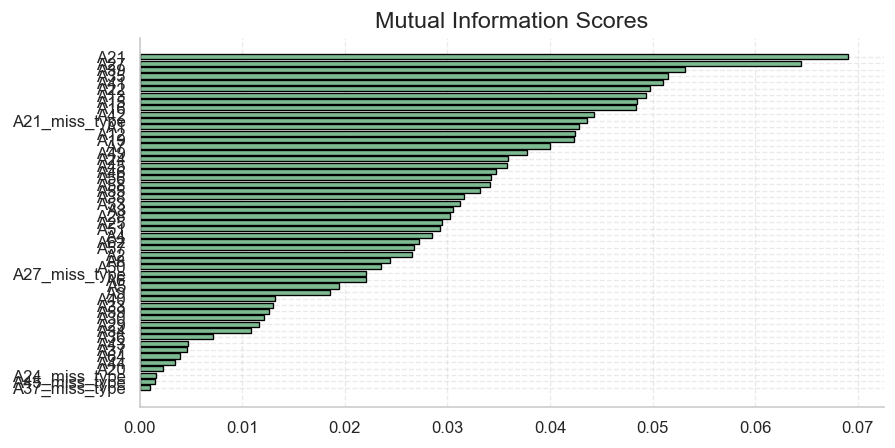

In [149]:
plot_mututal_info_scores(mi_scores)

In [150]:
mi_scores.describe()

count    53.000000
mean      0.028525
std       0.017235
min       0.000978
25%       0.012954
50%       0.029517
75%       0.042332
max       0.069089
Name: mi_scores, dtype: float64

In [151]:
mi_drop_columns = list(mi_scores[mi_scores < 0.015].index.astype(str))
for i in trad_columns:
    if i in mi_drop_columns:
        mi_drop_columns.pop(mi_drop_columns.index(i))
X_train_mi = X_train_imputed.drop(columns=mi_drop_columns)
X_test_mi = X_test_imputed.drop(columns=mi_drop_columns)

### Обработка выбросов

In [152]:
cat_cols_1 = [col for col in X_train_mi.columns if col.endswith('_miss_type')]
num_cols_1 = [col for col in X_train_mi.columns if col not in cat_cols_1]
# for i in num_cols:
#     plt.hist(X_dropped[i], bins=30)
#     plt.show()

Для избавления от выбросов используем IQR, с оговоркой. Датасет - небольшой, а признаков много, и если удалять все выбросы по всем признакам то данных для обучения остается очень мало, так же выбросы для финансовых коэффициентов могут нести полезную информацию, поэтому совсем избавляться от них не будем.

In [153]:
X_train_cleaned = X_train_mi.drop(index=get_iqr_indexes(X_train_imputed, num_cols_1, threshold=75))
y_train = y_train.loc[X_train_cleaned.index]
print(len(X_train_cleaned), len(y_train))
y_train.value_counts(normalize=True)

4543 4543


class
0    0.934405
1    0.065595
Name: proportion, dtype: float64

In [154]:
X_test_cleaned = X_test_mi
print(len(X_test_cleaned), len(y_test))
y_test.value_counts(normalize=True)

871 871


class
0    0.920781
1    0.079219
Name: proportion, dtype: float64

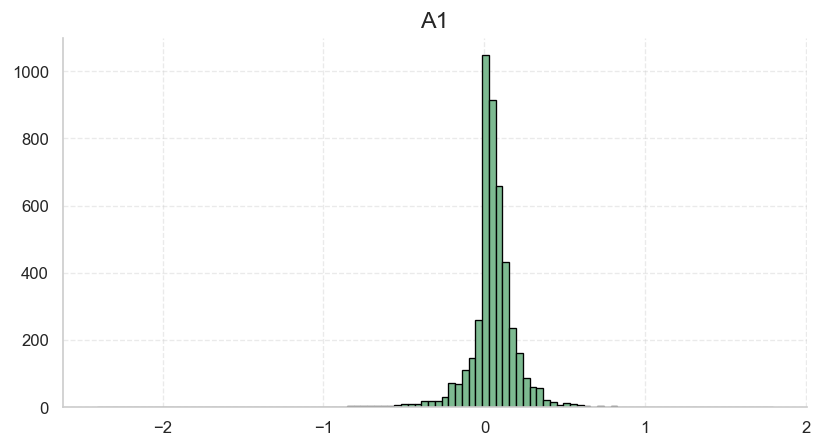

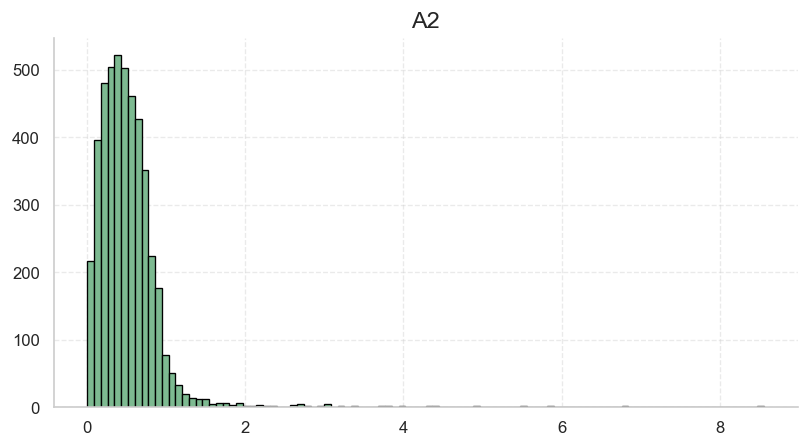

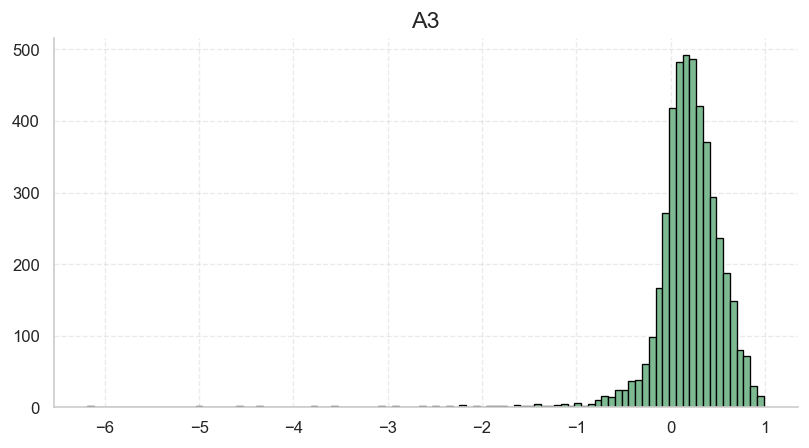

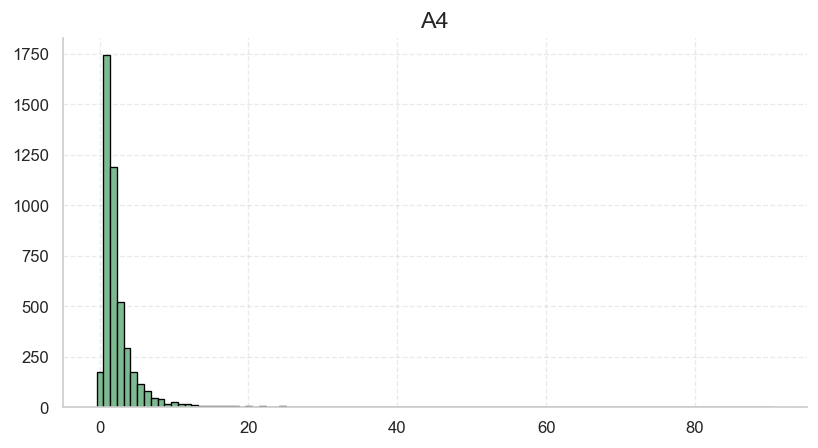

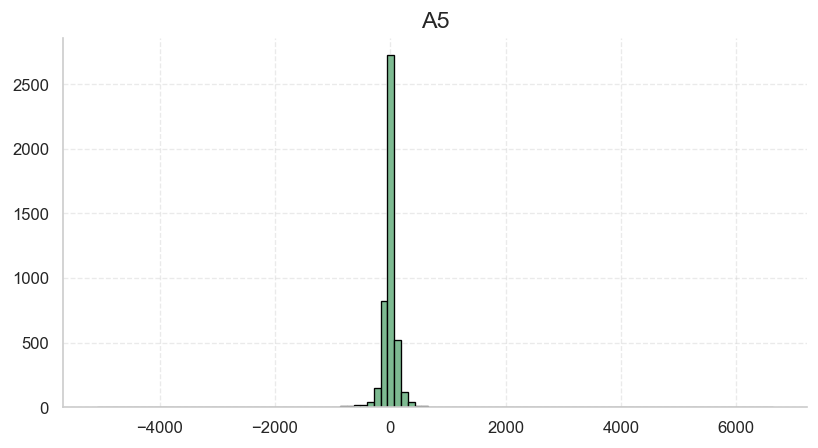

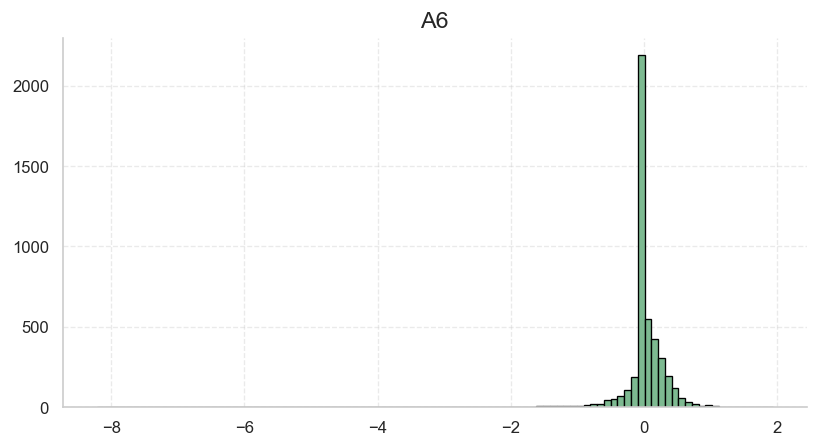

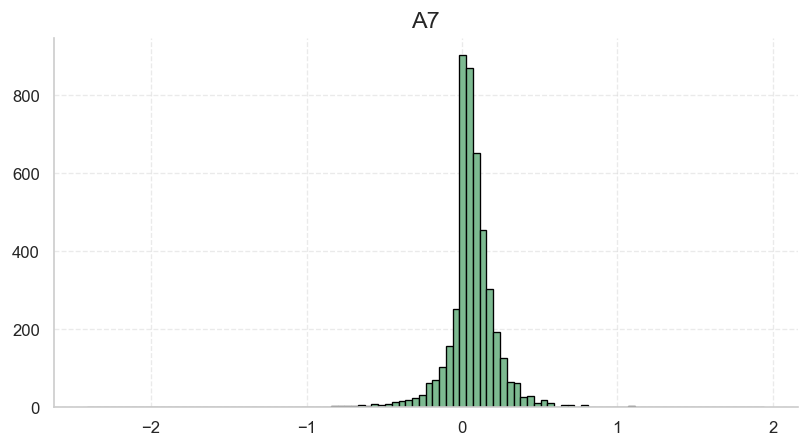

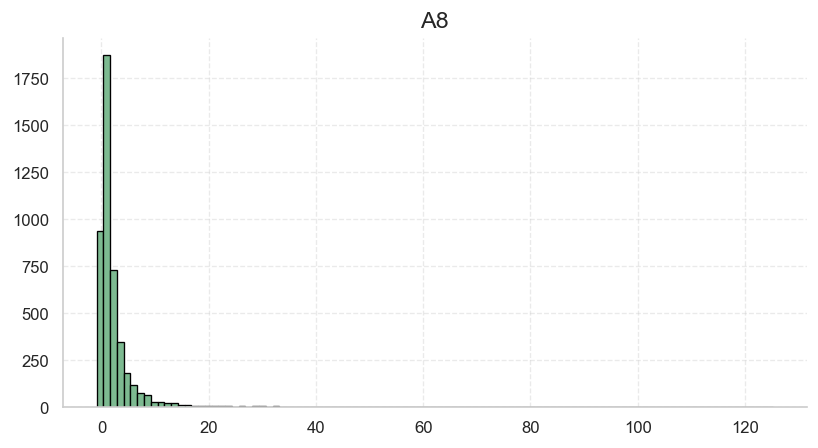

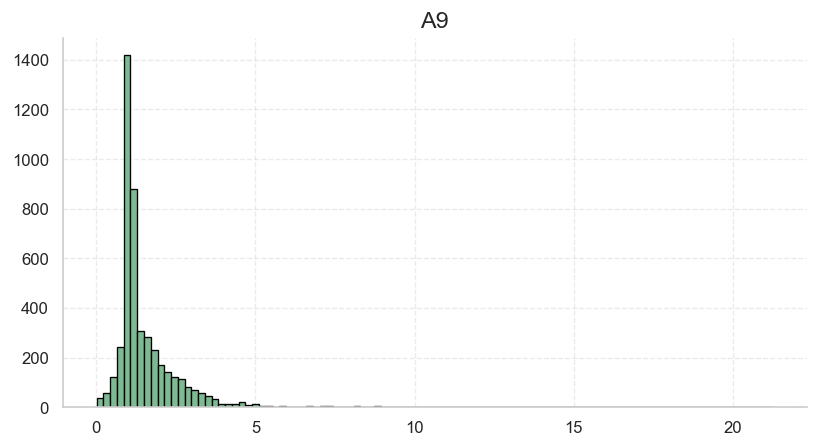

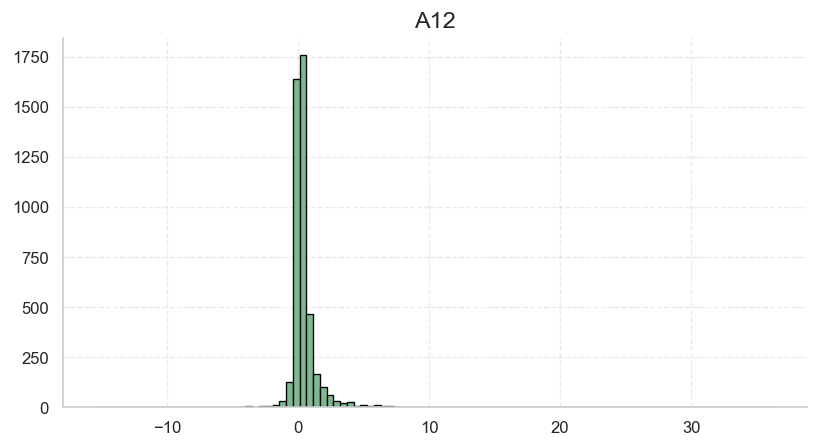

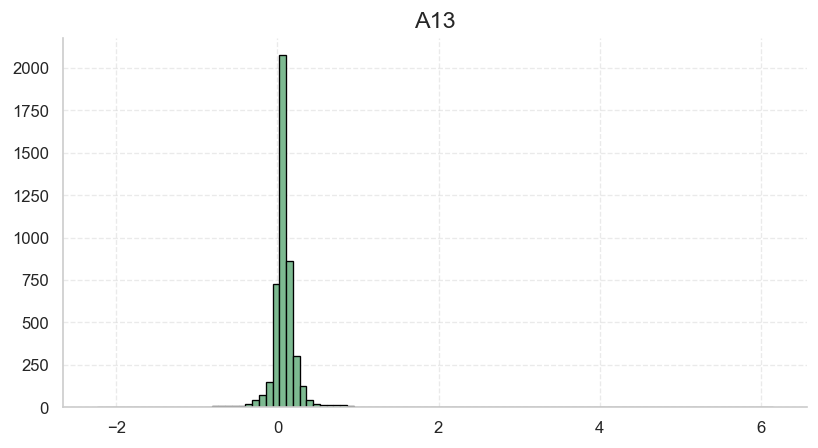

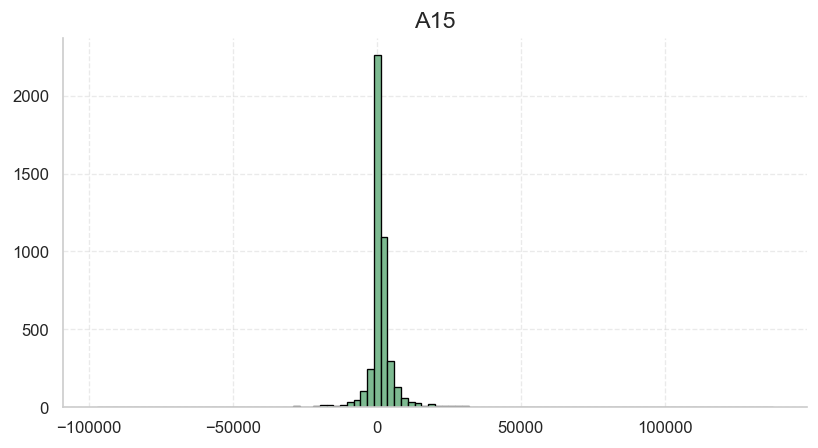

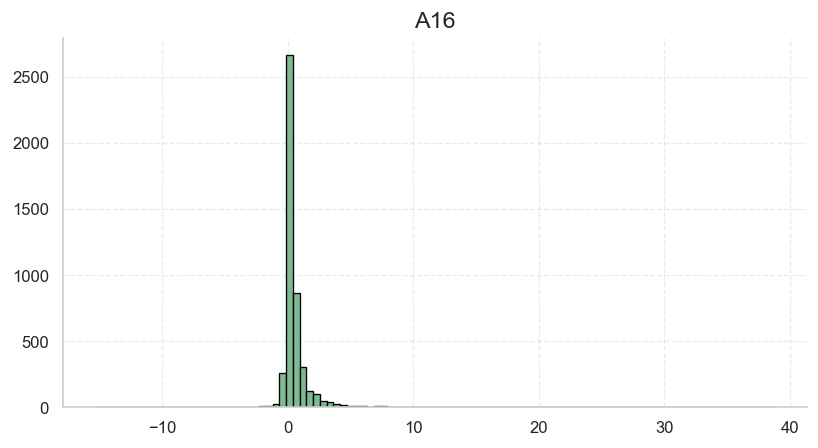

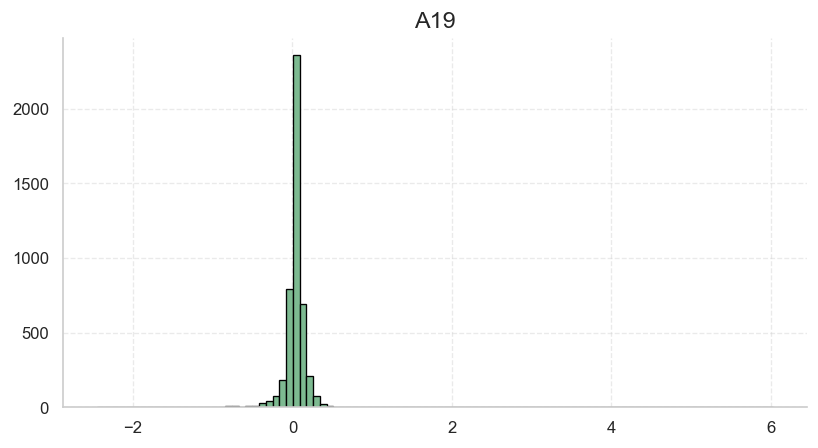

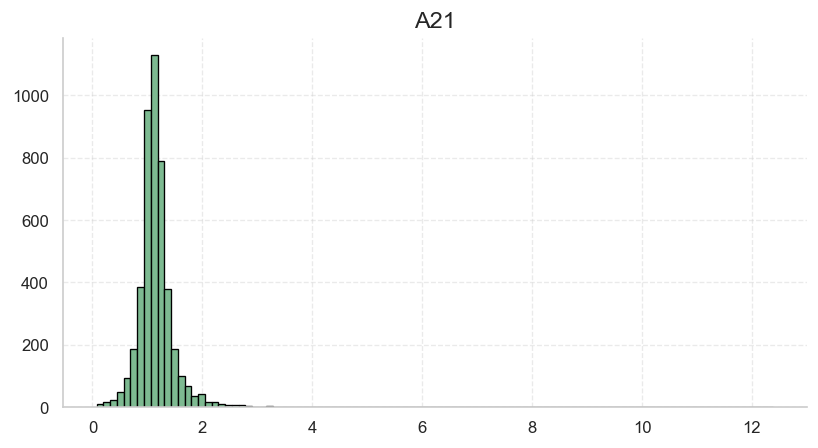

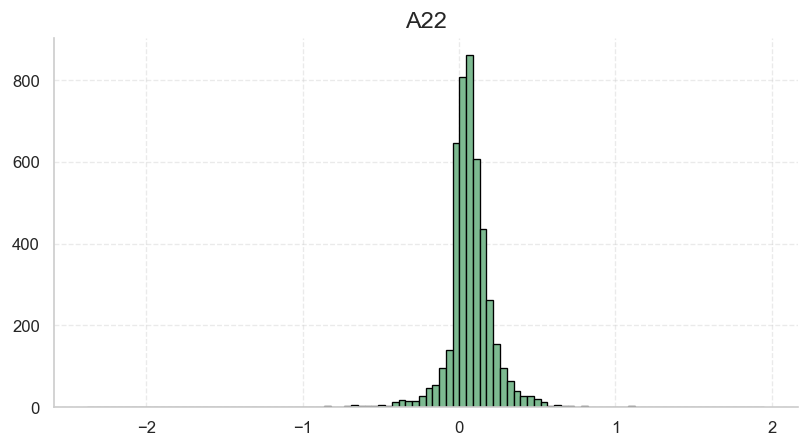

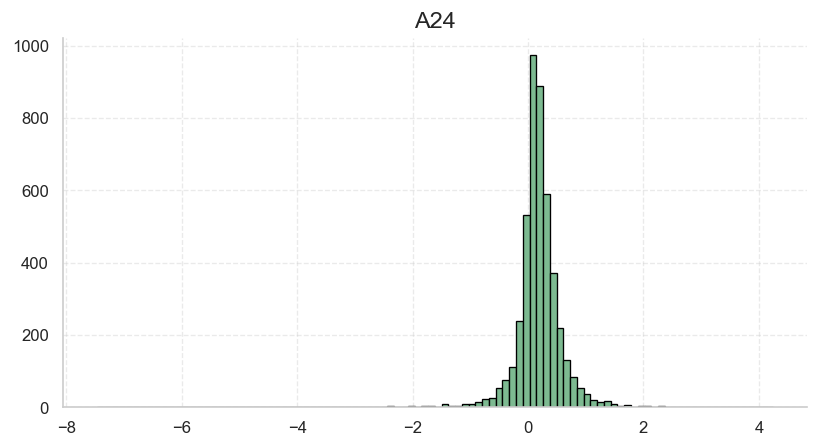

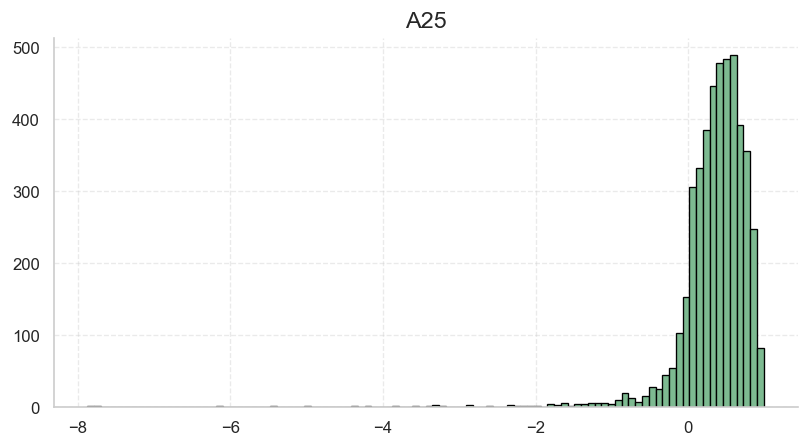

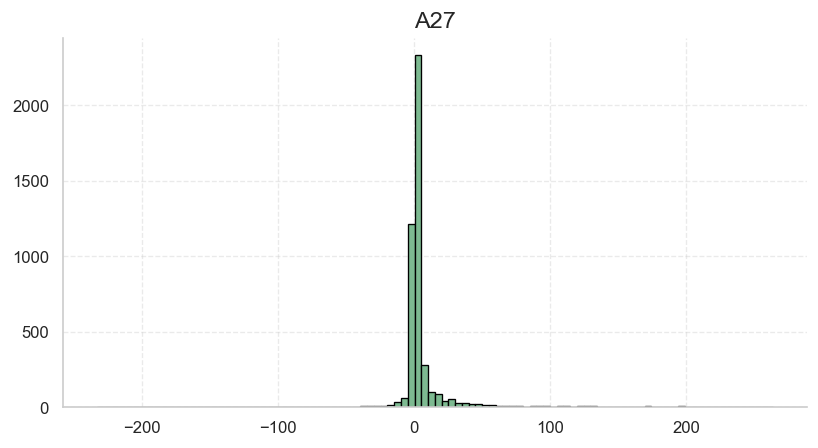

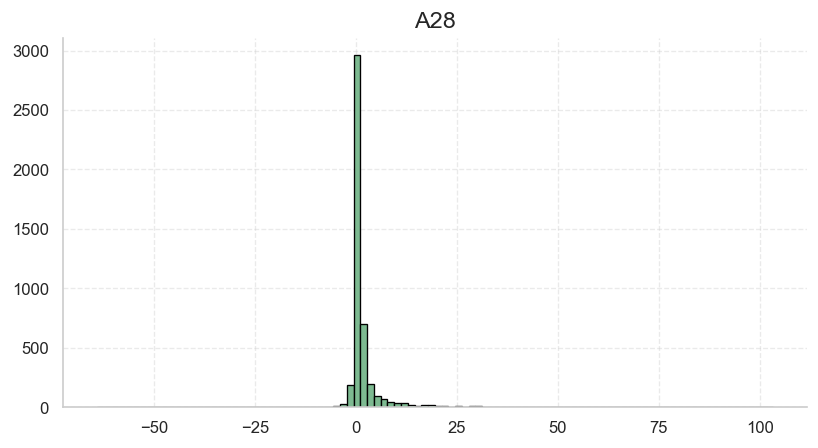

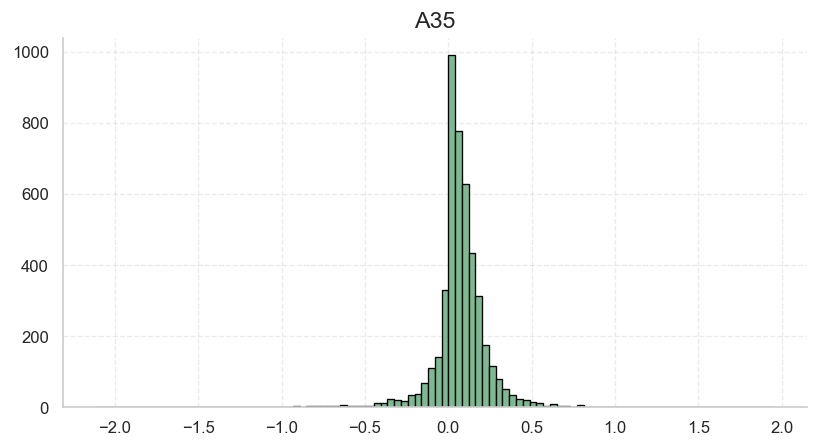

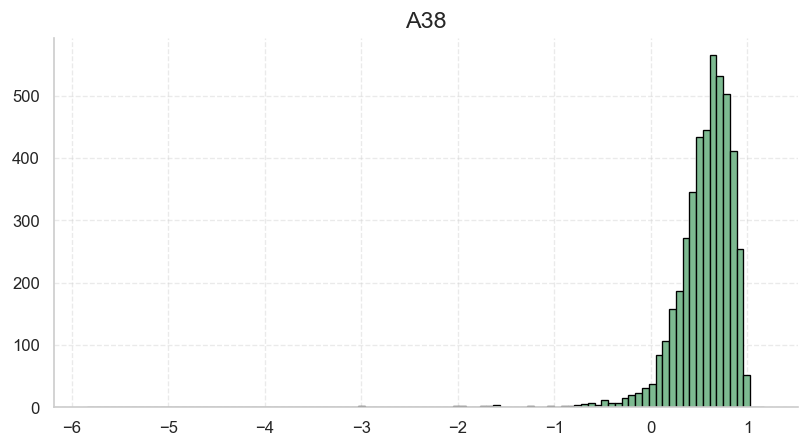

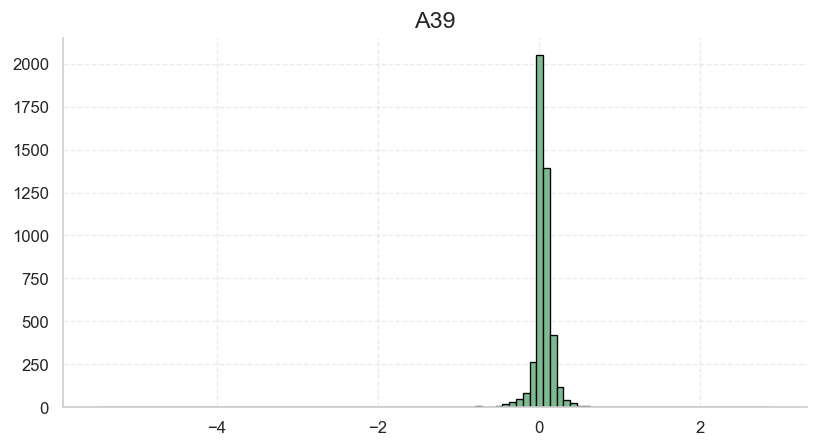

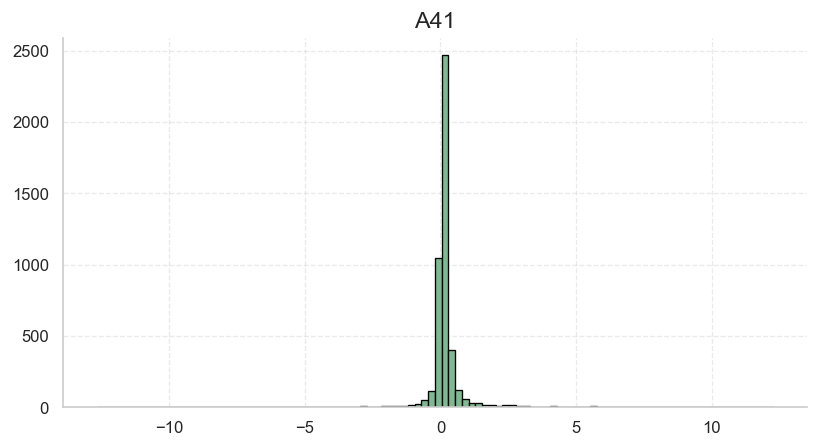

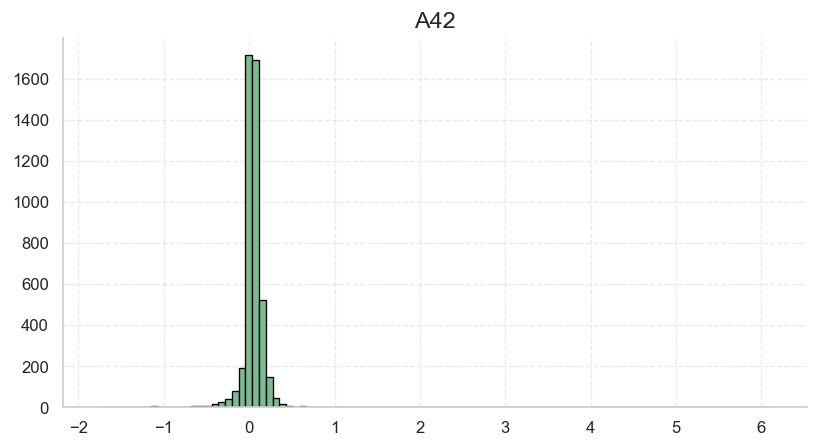

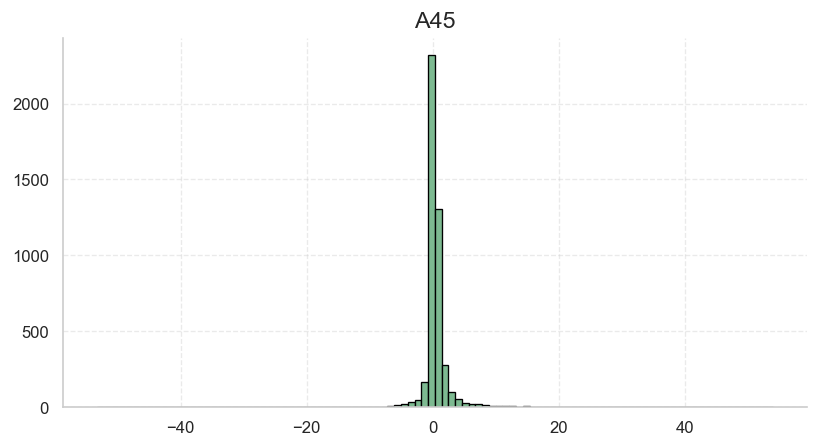

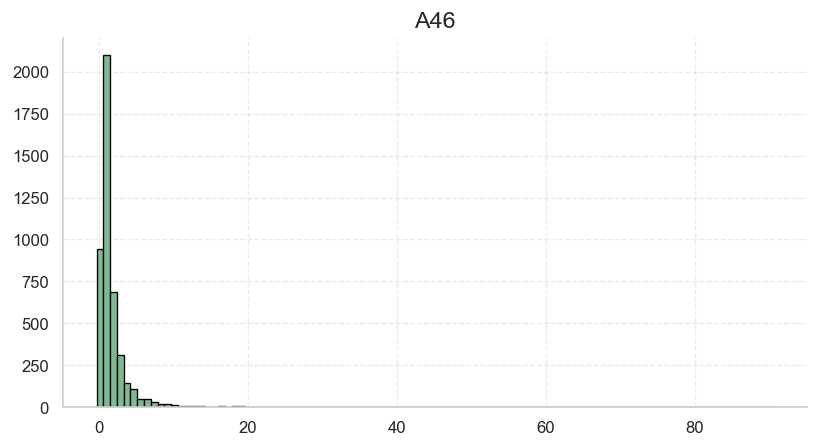

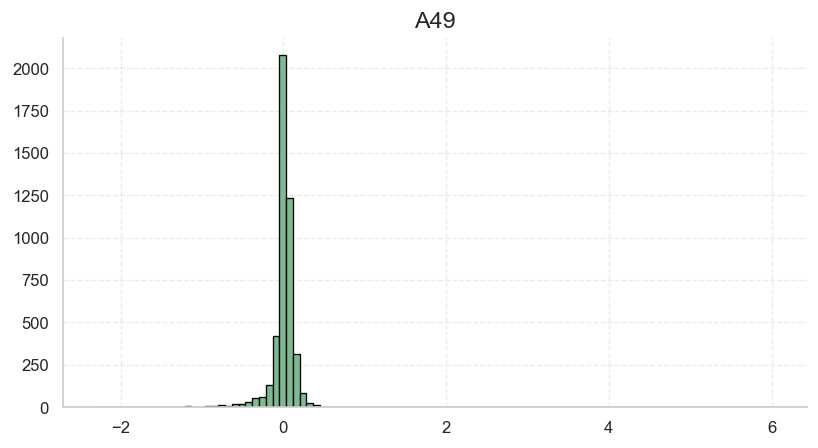

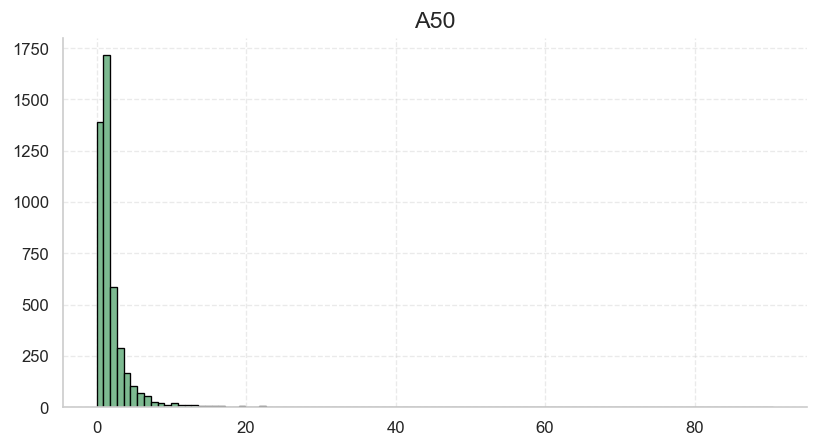

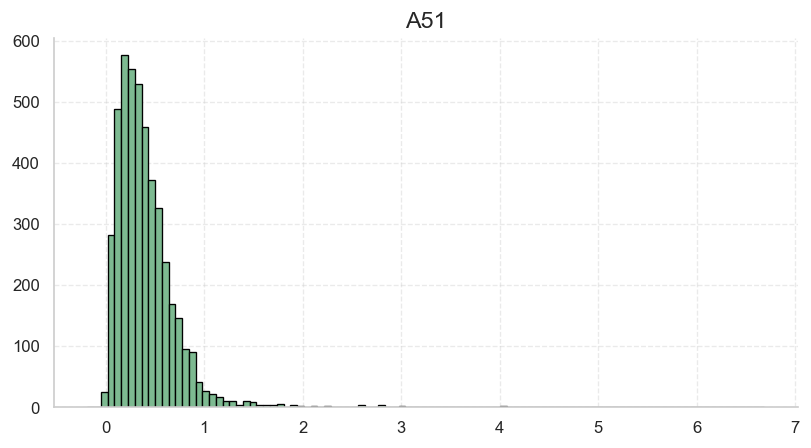

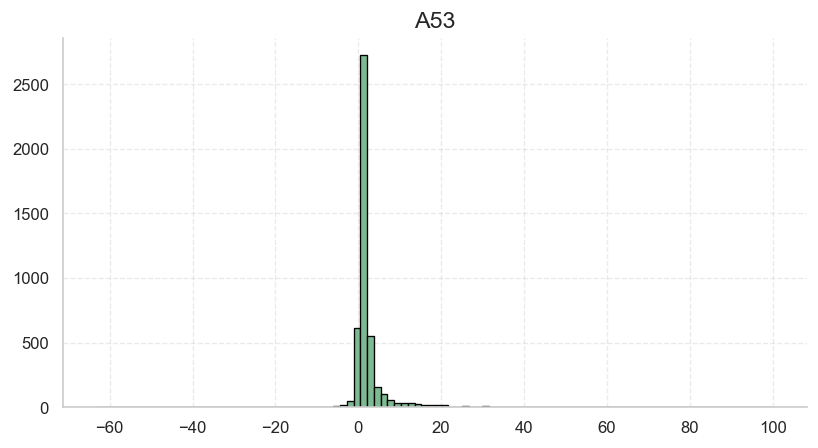

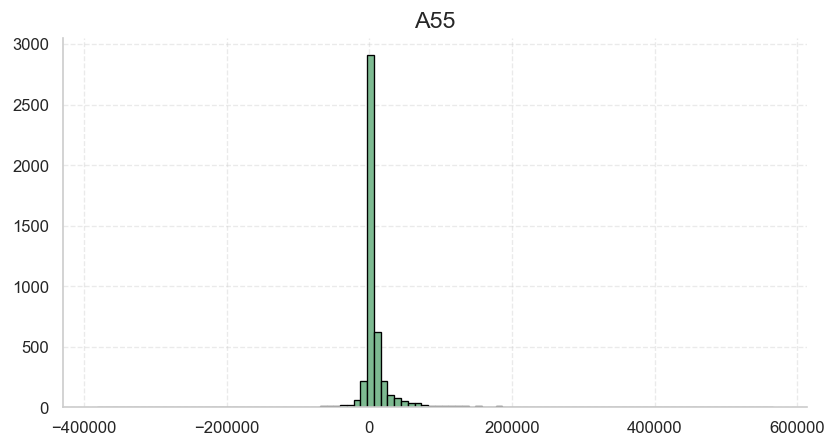

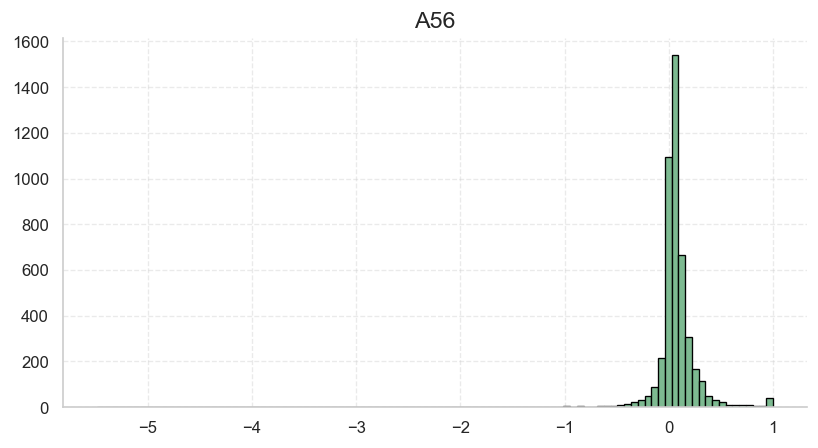

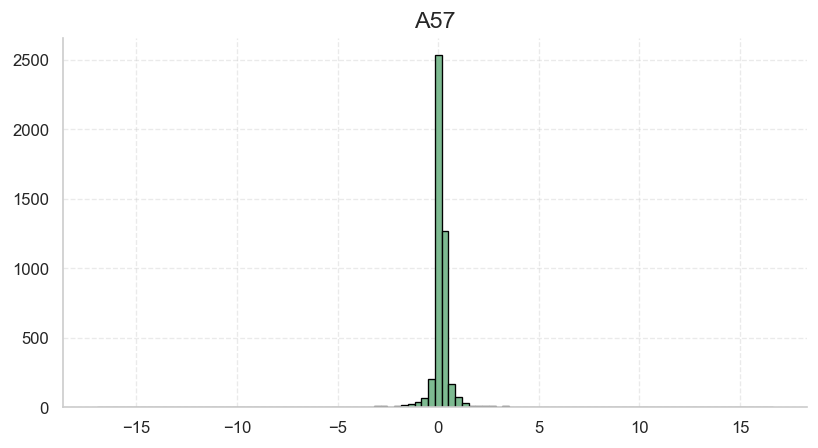

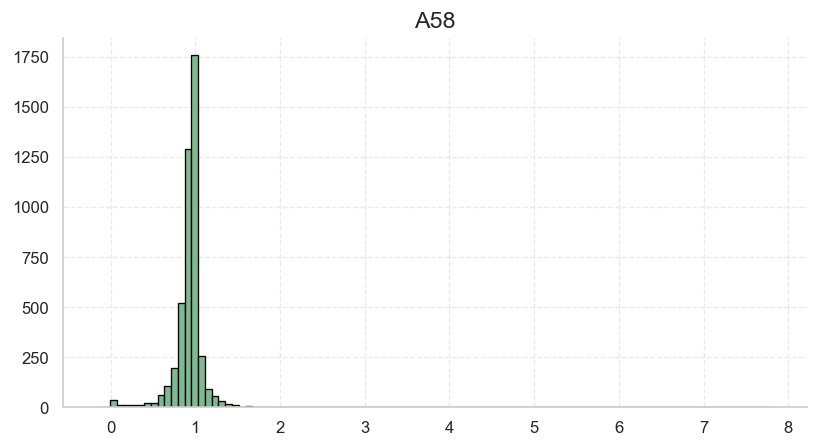

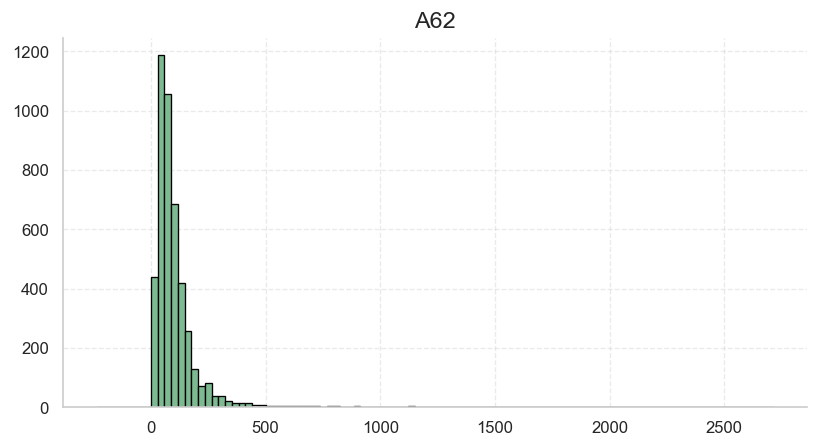

In [155]:
for i in num_cols_1:
    plt.hist(X_train_cleaned[i], bins=100)
    plt.title(i)
    plt.show()

Следующие признаки имеют подозрение на константное распределение:
- A37
- A6
- A59


Для проверки стоит посмотреть на квантили и количество различных значений в этих признаках

In [156]:
X[['A6', 'A37', 'A59']].describe().T

,count,mean,std,min,25%,50%,75%,max
A6,5907.0,0.022584,9.992080,-463.8900,0.000000,0.000000,0.108725,543.25
A37,3362.0,114.025985,1597.055061,-4.3258,1.294925,3.656400,15.230250,67922.00
A59,5907.0,0.279319,5.840554,-184.9800,0.000000,0.005675,0.205215,308.15


In [157]:
for i in ['A6', 'A37', 'A59']:
    print(X[i].value_counts())

A6
 0.00000    2274
 0.13521       3
 0.39721       3
-0.15083       3
 0.41879       2
            ... 
-1.32980       1
-0.57805       1
-0.17905       1
-0.10886       1
-0.10537       1
Name: count, Length: 3539, dtype: int64
A37
2.49270      4
1.53380      3
4.10230      3
2.77270      3
84.27500     2
            ..
0.37850      1
17.03600     1
3.60650      1
0.23908      1
205.69000    1
Name: count, Length: 3260, dtype: int64
A59
 0.000000    2547
 0.100660       3
 0.127770       3
 0.002640       3
 0.014242       2
             ... 
 1.259400       1
-0.018084       1
-0.522430       1
 6.092400       1
 0.003196       1
Name: count, Length: 3254, dtype: int64


В связи с низкой информативностью эти признаки будут удалены в **финальной обработке выборок**.


### Масштабирование

In [158]:
from sklearn.preprocessing import StandardScaler

cat_cols = [col for col in X_train_cleaned.columns if col.endswith('_miss_type')]
num_cols = [col for col in X_train_cleaned.columns if col not in cat_cols]

scaler = StandardScaler()

X_train_scaled = X_train_cleaned
X_test_scaled = X_test_cleaned

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

### Финальные train и test выборки

##### Для традиционных моделей:

In [159]:
X_train_final_trad = X_train_cleaned
X_test_final_trad = X_test_cleaned
#X_final_trad = X_imputed

##### Для ML:

In [160]:
X_train_final = X_train_scaled
X_test_final = X_test_scaled
for i in ['A6', 'A37', 'A59']:
    if i in X_train_final.columns:
        X_train_final = X_train_final.drop(columns=i)
    if i in X_test_final.columns:
        X_test_final = X_test_final.drop(columns=i)

# Модели

### Традиционные модели

#### Подготовка

##### Функции

In [161]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

def trad_validation_info(y_valid, y_pred, printing_results=False):
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    accuracy = accuracy_score(y_valid, y_pred)
    
    if printing_results:
        print("Accuracy:", accuracy)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1:", f1)
    
    labels = ["Accuracy", "Precision", "Recall", "F1"]
    values = [accuracy, precision, recall, f1]
    d = dict(zip(labels, values))
    return d

In [162]:
from sklearn.base import BaseEstimator, ClassifierMixin

##### Двухфакторная модель Э.Альтмана

In [163]:
class two_factor_Altman(BaseEstimator, ClassifierMixin):
    '''
    Z = −0.3877 − 1.073 * X1 + 0.0579 * X2
    
    X1 = A4 = Оборотные активы / Краткосрочные обязательства = current assets / short-term liabilities
    
    X2 = A2 = Заемные средства /Активы = total liabilities / total assets
    '''
    def __init__(self):
        self.weights = [
            -0.3877,
            -1.073,
            0.0579
        ]
        self.threshold = 0
        
    def fit(self, X, y):
        return self
        
    def predict(self, X):
        y_pred = pd.Series((self.weights[0] + self.weights[1] * X['A4'] + self.weights[2] * X['A2']) > self.threshold).astype(int)
        return y_pred

##### Пятифакторная модель Э.Альтмана для частных компаний

In [164]:
class five_factor_Altman(BaseEstimator, ClassifierMixin):
    '''
    Z = 1.2 * X1 + 1.4 * X2 + 3.3 * X3 + 0.6 * X4 + X5
    
    X1 = A3 = Working Capital / Total Assets = (current assets − current liabilities) / total assets
    
    X2 = A6 = Retained Earnings / Total Assets = retained earnings / total assets
    
    X3 = A7 = EBIT / Total Assets = operating profit / total assets
    
    X4 = A8 = Equity / Total Liabilities = book value of equity / total liabilities
    
    X5 = A9 = Sales / Total Assets = sales / total assets
    '''
    def __init__(self):
        self.weights = [
            1.2,
            1.4,
            3.3,
            0.6,
            1
        ]
        self.threshold = 1.81
        
    def fit(self, X, y):
        return self
        
    def predict(self, X):
        y_pred = pd.Series((self.weights[0] * X['A3'] + self.weights[1] * X['A6'] + self.weights[2] * X['A7'] + 
                           self.weights[3] * X['A8'] + self.weights[4] * X['A9']) < self.threshold).astype(int)
        return y_pred

##### Модель Z-счета Альтмана

In [165]:
class Z_count_Altman(BaseEstimator, ClassifierMixin):
    '''
    Z = 0.717 * X1 + 0.847 * X2 + 3.107 * X3 + 0.420 * X4 + 0.998 * X5
    
    X1 = A3 = Working Capital / Total Assets = (current assets − current liabilities) / total assets

    X2 = A6 = Retained Earnings / Total Assets = retained earnings / total assets
    
    X3 = A7 = EBIT / Total Assets = operating profit / total assets
    
    X4 = A8 = Equity / Total Liabilities = book value of equity / total liabilities
    
    X5 = A9 = Sales / Total Assets = sales / total assets
    '''
    def __init__(self):
        self.weights = [
            0.717,
            0.847,
            3.107,
            0.420,
            0.998
        ]
        self.threshold = 1.23
        
    def fit(self, X, y):
        return self
        
    def predict(self, X):
        y_pred = pd.Series((self.weights[0] * X['A3'] + self.weights[1] * X['A6'] + self.weights[2] * X['A7'] + 
                           self.weights[3] * X['A8'] + self.weights[4] * X['A9']) < self.threshold).astype(int)
        return y_pred

##### Модель Лиса

In [166]:
class Lis_model(BaseEstimator, ClassifierMixin):
    '''
    Z = 0.063 * K1 + 0.092 * K2 + 0.057 * K3 + 0.001 * K4
    
    K1 = A3 = Working Capital / Total Assets = (current assets − current liabilities) / total assets
    
    K2 = (Profit Before Tax) / Total Assets ~ A7 = EBIT / Total Assets
    
    K3 = A6 = Retained Earnings / Total Assets = retained earnings / total assets
    
    K4 = A8 = Equity / Total Liabilities = book value of equity / total liabilities
    '''
    def __init__(self):
        self.weights = [
            0.063,
            0.092,
            0.057,
            0.001
        ]
        self.threshold = 0.037
        
    def fit(self, X, y):
        return self
        
    def predict(self, X):
        y_pred = pd.Series((self.weights[0] * X['A3'] + self.weights[1] * X['A7'] + self.weights[2] * X['A6'] + 
                           self.weights[3] * X['A8']) < self.threshold).astype(int)
        return y_pred

#### Оценка традиционных моделей

In [167]:
traditional_classifiers = [
    ('two_factor_Altman', two_factor_Altman()),
    ('five_factor_Altman', five_factor_Altman()),
    ('Lis_model', Lis_model()),
    ('Z_count_Altman', Z_count_Altman())
]

In [168]:
learning_info_trad = dict()

def learn_model_trad(i):
    y_pred = i[1].predict(X_test_final_trad)

    learning_info_trad[i[0]] = trad_validation_info(y_test, y_pred)
    print(f'Classifier {i[0]} done!')
    
for i in traditional_classifiers:
    learn_model_trad(i)

Classifier two_factor_Altman done!
Classifier five_factor_Altman done!
Classifier Lis_model done!
Classifier Z_count_Altman done!


In [169]:
info = pd.DataFrame(data=learning_info_trad).T.sort_values(by='F1', ascending=False)
info

,Accuracy,Precision,Recall,F1
two_factor_Altman,0.717566,0.171004,0.666667,0.272189
Lis_model,0.471871,0.117417,0.869565,0.206897
Z_count_Altman,0.415614,0.104317,0.840580,0.185600
five_factor_Altman,0.392652,0.103448,0.869565,0.184900


### Для данной задачи будут использованы следующие модели машинного обучения:
* LogisticRegression
* RandomForestClassifier
* GradientBoostingClassifier
* HistGradientBoostingClassifier

In [201]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

### *Функции*

In [171]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    accuracy_score
)

def validation_info(y_valid, y_pred, y_proba, printing_results=False):
    precision = precision_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred)
    f1 = f1_score(y_valid, y_pred)
    pr_auc = average_precision_score(y_valid, y_proba)
    roc_auc = roc_auc_score(y_valid, y_proba)
    accuracy = accuracy_score(y_valid, y_pred)
    
    if printing_results:
        print("Accuracy:", accuracy)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1:", f1)
        print("PR-AUC:", pr_auc)
        print("ROC-AUC:", roc_auc)  
        
        print("\nConfusion matrix:")
        print(confusion_matrix(y_valid, y_pred))
        
        print("\nClassification report:")
        print(classification_report(y_valid, y_pred))
    
    labels = ["Accuracy", "Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"]
    values = [accuracy, precision, recall, f1, pr_auc, roc_auc]
    d = dict(zip(labels, values))
    return d

In [172]:
from sklearn.model_selection import cross_validate

def cross_validation_info(model, X, y, cv=5, printing_results=False, scoring=['accuracy', 'precision', 'recall', 'f1', 'average_precision', 'roc_auc', 'balanced_accuracy']):
    scores = pd.DataFrame(data=cross_validate(model, X, y, cv=cv, scoring=scoring)).mean()

    if printing_results:
        print(scores)

    return scores

In [173]:
def plot_scores(i, df):
    scores = df.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(ticks, scores)
    # plt.yticks(width, ticks)
    plt.title(i)
    plt.show()

In [174]:
from sklearn.inspection import permutation_importance

def plot_feature_importance(
    model,
    X,
    y,
    top_n=None,
    scoring='f1',
    n_repeats=10,
    random_state=33
):

    result = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': result.importances_mean,
        'Std': result.importances_std
    })

    importance = importance.sort_values(
        'Importance',
        ascending=False
    ).head(top_n)

    sns.barplot(
        data=importance,
        x='Importance',
        y='Feature',
        edgecolor='black',
        linewidth=0.8
    )

    plt.title(f'{type(model).__name__} Feature Importance')
    plt.xlabel('Mean decrease of score')
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

    return importance

### Первичное обучение моделей

In [175]:
# classifiers = [('LogisticRegression', 
#                 LogisticRegression(
#                     max_iter=500,
#                     random_state=33
#                 )), 
               
#                ('RandomForestClassifier', 
#                 RandomForestClassifier(
#                     random_state=33
#                 )), 
               
#                ('HGBoost', 
#                 HistGradientBoostingClassifier(
#                     random_state=33,
#                      categorical_features=cat_cols,
#                 )),
               
#                ('GradientBoost', 
#                 GradientBoostingClassifier(
#                     random_state=33,
#                 ))
#               ]

In [176]:
# learning_info = dict()
# cross_val_learning_info = dict()

# def learn_model(i):

#     cross_val_learning_info[i[0]] = cross_validation_info(i[1], X_train_final, y_train)
    
#     i[1].fit(X_train_final, y_train)

#     y_pred = i[1].predict(X_test_final)
    
#     if hasattr(i[1], "predict_proba"):
#         y_proba = i[1].predict_proba(X_test_final)[:,1]

#     if hasattr(i[1], "decision_function"):
#         y_proba = i[1].decision_function(X_test_final)

#     learning_info[i[0]] = validation_info(y_test, y_pred, y_proba)
#     print(f'Classifier {i[0]} done!')
    
# for i in classifiers:
#     learn_model(i)

#### Кросс-валидация

In [177]:
# cross_val_info = pd.DataFrame(data=cross_val_learning_info).T
# cross_val_info

### Тюнинг моделей

In [178]:
X_train_s, X_valid_s, y_train_s, y_valid_s = train_test_split(X_train_final, y_train, test_size=0.2)

In [262]:
import optuna
from sklearn.metrics import f1_score

#### Logistic Regression

In [266]:
def objective(trial): 
    max_iter = trial.suggest_int(
        "max_iter",
        100,
        1000
    )

    C = trial.suggest_float(
        "C",
        0,
        1.0
    )

    solver = trial.suggest_categorical(
        'solver',
        ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
    )
    
    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=max_iter,
        class_weight='balanced',
        
        random_state=33
    )

    model.fit(X_train_s, y_train_s)

    y_pred_s = model.predict(X_valid_s)

    bal_score = f1_score(y_valid_s, y_pred_s)

    return bal_score

In [267]:
study = optuna.create_study(study_name="logistic_regression_study", direction="maximize")

[I 2026-08-02 12:15:23,903] A new study created in memory with name: logistic_regression_study


In [268]:
study.optimize(
    objective,
    n_trials=100
)

[I 2026-08-02 12:15:25,279] Trial 0 finished with value: 0.38235294117647056 and parameters: {'max_iter': 499, 'C': 0.07681259195022638, 'solver': 'liblinear'}. Best is trial 0 with value: 0.38235294117647056.
C:\Users\yafil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2026-08-02 12:15:25,659] Trial 1 finished with value: 0.43243243243243246 and parameters: {'max_iter': 387, 'C': 0.235047332019506, 'solver': 'sag'}. Best is trial 1 with value: 0.43243243243243246.
[I 2026-08-02 12:15:25,691] Trial 2 finished with value: 0.44692737430167595 and parameters: {'max_iter': 877, 'C': 0.46085991035209917, 'solver': 'newton-cg'}. Best is trial 2 with value: 0.44692737430167595.
C:\Users\yafil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the co

In [269]:
study.best_params
# bal_accuracy {'max_iter': 311, 'C': 0.8164404211041757, 'solver': 'newton-cholesky'}
# f1 {'max_iter': 719, 'C': 0.952909915871754, 'solver': 'lbfgs'}

{'max_iter': 719, 'C': 0.952909915871754, 'solver': 'lbfgs'}

#### Random Forest

In [291]:
def objective(trial):
    n_estimators = trial.suggest_int(
        "n_estimators",
        50,
        500
    )
    
    max_depth = trial.suggest_int(
        "max_depth",
        2,
        20
    )
    
    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        5
    )

    criterion = trial.suggest_categorical(
        "criterion",
        ['gini', 'entropy', 'log_loss']
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        5
    )
    
    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2"]
    )

    model = RandomForestClassifier(
        criterion=criterion,
        min_samples_split=min_samples_split,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced",
        random_state=33
    )

    model.fit(X_train_s, y_train_s)

    y_pred_s = model.predict(X_valid_s)

    bal_score = f1_score(y_valid_s, y_pred_s)

    return bal_score

In [293]:
study = optuna.create_study(study_name="random_forest_study", direction="maximize")

[I 2026-08-02 12:37:14,804] A new study created in memory with name: random_forest_study


In [294]:
study.optimize(
    objective,
    n_trials=35
)

[I 2026-08-02 12:37:17,597] Trial 0 finished with value: 0.6666666666666666 and parameters: {'n_estimators': 133, 'max_depth': 15, 'min_samples_leaf': 1, 'criterion': 'log_loss', 'min_samples_split': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6666666666666666.
[I 2026-08-02 12:37:18,806] Trial 1 finished with value: 0.5538461538461539 and parameters: {'n_estimators': 122, 'max_depth': 7, 'min_samples_leaf': 1, 'criterion': 'log_loss', 'min_samples_split': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2026-08-02 12:37:20,207] Trial 2 finished with value: 0.6407766990291263 and parameters: {'n_estimators': 140, 'max_depth': 19, 'min_samples_leaf': 2, 'criterion': 'log_loss', 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.6666666666666666.
[I 2026-08-02 12:37:21,756] Trial 3 finished with value: 0.5 and parameters: {'n_estimators': 251, 'max_depth': 3, 'min_samples_leaf': 4, 'criterion': 'log_loss', 'min_sampl

In [295]:
study.best_params

# bal accuracy:
# {'n_estimators': 127,
#  'max_depth': 5,
#  'min_samples_leaf': 4,
#  'criterion': 'entropy',
#  'min_samples_split': 2,
#  'max_features': 'sqrt'}

# f1:
# {'n_estimators': 199,
#  'max_depth': 16,
#  'min_samples_leaf': 1,
#  'criterion': 'log_loss',
#  'min_samples_split': 3,
#  'max_features': 'sqrt'}

{'n_estimators': 99,
 'max_depth': 13,
 'min_samples_leaf': 2,
 'criterion': 'log_loss',
 'min_samples_split': 4,
 'max_features': 'sqrt'}

#### HGBoost

In [287]:
def objective(trial):
    max_features = trial.suggest_float(
        'max_features',
        0,
        1.0
    )

    l2_regularization = trial.suggest_float(
        'l2_regularization',
        0,
        1.0
    )
    
    max_iter = trial.suggest_int(
        "max_iter",
        50,
        200
    )
    
    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        10
    )

    model = HistGradientBoostingClassifier(
        max_leaf_nodes = None,
        max_depth=None,
        categorical_features=cat_cols,
        class_weight="balanced",

        max_features=max_features,
        l2_regularization=l2_regularization,
        max_iter=max_iter,
        min_samples_leaf=min_samples_leaf,
        
        random_state=33
    )

    model.fit(X_train_s, y_train_s)

    y_pred_s = model.predict(X_valid_s)

    bal_score = f1_score(y_valid_s, y_pred_s)

    return bal_score

In [288]:
study = optuna.create_study(study_name="hgboost_study", direction="maximize")

[I 2026-08-02 12:28:59,823] A new study created in memory with name: hgboost_study


In [289]:
study.optimize(
    objective,
    n_trials=35
)

[I 2026-08-02 12:29:04,291] Trial 0 finished with value: 0.7216494845360825 and parameters: {'max_features': 0.9628376174861387, 'l2_regularization': 0.9827346408777147, 'max_iter': 158, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7216494845360825.
[I 2026-08-02 12:29:07,913] Trial 1 finished with value: 0.6804123711340206 and parameters: {'max_features': 0.5905465262138632, 'l2_regularization': 0.1895443953116659, 'max_iter': 63, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7216494845360825.
[I 2026-08-02 12:29:12,537] Trial 2 finished with value: 0.6526315789473685 and parameters: {'max_features': 0.06075903964480489, 'l2_regularization': 0.5249218667207672, 'max_iter': 158, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7216494845360825.
[I 2026-08-02 12:29:16,900] Trial 3 finished with value: 0.7070707070707071 and parameters: {'max_features': 0.5352733052790285, 'l2_regularization': 0.2615968858128932, 'max_iter': 131, 'min_samples_leaf': 10}. Best is tri

In [290]:
study.best_params
# bal_accuracy:
# {'max_features': 0.22057798352279387,
#  'l2_regularization': 0.7209737130521496,
#  'max_iter': 54,
#  'min_samples_leaf': 3}

# f1
# {'max_features': 0.8254759455766282,
#  'l2_regularization': 0.01565591960535534,
#  'max_iter': 183,
#  'min_samples_leaf': 8}

{'max_features': 0.8254759455766282,
 'l2_regularization': 0.01565591960535534,
 'max_iter': 183,
 'min_samples_leaf': 8}

#### GradientBoost

In [296]:
def objective(trial):
    n_estimators=trial.suggest_int(
        'n_estimators',
        25,
        250
    )
    
    max_features = trial.suggest_float(
        'max_features',
        0,
        1.0
    )

    max_depth = trial.suggest_int(
        'max_depth',
        1,
        100
    )

    subsample = trial.suggest_float(
        'subsample',
        0,
        1.0
    )

    validation_fraction = trial.suggest_float(
        'validation_fraction',
        0,
        1.0
    )

    n_iter_no_change = trial.suggest_int(
        "n_iter_no_change",
        1,
        2000
    )

    min_weight_fraction_leaf = trial.suggest_float(
        'min_weight_fraction_leaf',
        0,
        0.5
    )
    
    
    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        50
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        50
    )
    
    model = GradientBoostingClassifier(
        max_leaf_nodes = None,

        validation_fraction=validation_fraction,
        n_iter_no_change=n_iter_no_change,
        max_features=max_features,
        max_depth=max_depth,
        subsample=subsample,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        
        random_state=33
    )

    model.fit(X_train_s, y_train_s)

    y_pred_s = model.predict(X_valid_s)

    bal_score = f1_score(y_valid_s, y_pred_s)

    return bal_score

In [297]:
study = optuna.create_study(study_name="gradient_boost_study", direction="maximize")

[I 2026-08-02 12:39:36,021] A new study created in memory with name: gradient_boost_study


In [298]:
study.optimize(
    objective,
    n_trials=35
)

[I 2026-08-02 12:39:37,319] Trial 0 finished with value: 0.5287356321839081 and parameters: {'n_estimators': 31, 'max_features': 0.5287069902769714, 'max_depth': 62, 'subsample': 0.4496863293169311, 'validation_fraction': 0.5003410592179616, 'n_iter_no_change': 19, 'min_weight_fraction_leaf': 0.10013386210304859, 'min_samples_leaf': 21, 'min_samples_split': 31}. Best is trial 0 with value: 0.5287356321839081.
[I 2026-08-02 12:39:47,357] Trial 1 finished with value: 0.6526315789473685 and parameters: {'n_estimators': 129, 'max_features': 0.9977718698496506, 'max_depth': 80, 'subsample': 0.6881455644452328, 'validation_fraction': 0.11365194040652815, 'n_iter_no_change': 436, 'min_weight_fraction_leaf': 0.44939576631857914, 'min_samples_leaf': 31, 'min_samples_split': 35}. Best is trial 1 with value: 0.6526315789473685.
[I 2026-08-02 12:39:47,600] Trial 2 finished with value: 0.5434782608695652 and parameters: {'n_estimators': 244, 'max_features': 0.33001219774647383, 'max_depth': 23, 'su

In [299]:
study.best_params

# bal accuracy
# {'n_estimators': 188,
#  'max_features': 0.369746907385478,
#  'max_depth': 10,
#  'subsample': 0.8547048128143927,
#  'validation_fraction': 0.015513561272382625,
#  'n_iter_no_change': 105,
#  'min_weight_fraction_leaf': 0.2673519686015537,
#  'min_samples_leaf': 13,
#  'min_samples_splitt': 37}

# f1
# {'n_estimators': 81,
#  'max_features': 0.4451317236841805,
#  'max_depth': 74,
#  'subsample': 0.8110400394583658,
#  'validation_fraction': 0.12551040805866992,
#  'n_iter_no_change': 1552,
#  'min_weight_fraction_leaf': 0.0005915706461618597,
#  'min_samples_leaf': 9,
#  'min_samples_split': 25}

{'n_estimators': 81,
 'max_features': 0.4451317236841805,
 'max_depth': 74,
 'subsample': 0.8110400394583658,
 'validation_fraction': 0.12551040805866992,
 'n_iter_no_change': 1552,
 'min_weight_fraction_leaf': 0.0005915706461618597,
 'min_samples_leaf': 9,
 'min_samples_split': 25}

#### Tuned Classifiers

In [312]:
tuned_classifiers = [('LogisticRegression', 
                LogisticRegression(
                    C=0.95,
                    random_state=33, 
                    max_iter=719, 
                    class_weight='balanced', 
                    solver='lbfgs'
                )),
               
               ('RandomForestClassifier', 
                RandomForestClassifier( 
                    random_state=33, 
                    class_weight='balanced',
                    
                    n_estimators = 150,
                    max_depth = 13,
                    min_samples_leaf = 2,
                    criterion = 'log_loss',
                    min_samples_split = 4,
                    max_features = 'sqrt'
                )), 
               
               ('HGBoost', 
                HistGradientBoostingClassifier(
                    random_state=33,
                    class_weight='balanced',
                    categorical_features=cat_cols,
                    
                    max_features = 0.82,
                    l2_regularization = 0.02,
                    max_iter = 150,
                    min_samples_leaf = 8
                )),
               
               ('GradientBoost', 
                GradientBoostingClassifier(
                    random_state = 33,
                    n_estimators = 150,
                    max_features = 0.45,
                    max_depth = 74,
                    subsample = 0.81,
                    validation_fraction = 0.013,
                    n_iter_no_change = 1552,
                    min_weight_fraction_leaf = 0.0005,
                    min_samples_leaf = 9,
                    min_samples_split = 25
                ))
              ]

### Оценка моделей машинного обучения

In [313]:
learning_info = dict()
cross_val_learning_info = dict()

def learn_model(i, threshold=None):

    cross_val_learning_info[i[0]] = cross_validation_info(i[1], X_train_final, y_train)
    
    i[1].fit(X_train_final, y_train)

    if hasattr(i[1], "predict_proba"):
        y_proba = i[1].predict_proba(X_test_final)[:,1]

    if hasattr(i[1], "decision_function"):
        y_proba = i[1].decision_function(X_test_final)

    if threshold:
        y_pred = pd.DataFrame(y_proba > threshold).astype(int)
    else:
        y_pred = i[1].predict(X_test_final)
    

    learning_info[i[0]] = validation_info(y_test, y_pred, y_proba)
    print(f'Classifier {i[0]} done!')
    
for i in tuned_classifiers:
    learn_model(i, threshold=-5)

Classifier LogisticRegression done!
Classifier RandomForestClassifier done!
Classifier HGBoost done!
Classifier GradientBoost done!


#### Кросс-валидация

In [314]:
cross_val_info = pd.DataFrame(data=cross_val_learning_info).T
cross_val_info

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_average_precision,test_roc_auc,test_balanced_accuracy
LogisticRegression,0.044058,0.013596,0.889937,0.348238,0.771864,0.479581,0.565764,0.900211,0.835049
RandomForestClassifier,1.787750,0.068282,0.953994,0.657940,0.624181,0.639895,0.666756,0.933654,0.800665
HGBoost,3.482962,0.034139,0.965662,0.813488,0.620791,0.703357,0.762858,0.938294,0.805331
GradientBoost,18.943453,0.114864,0.961478,0.817856,0.530056,0.641768,0.710173,0.932320,0.760906


#### Валидация на тестовой выборке

In [315]:
info = pd.DataFrame(data=learning_info).T
info

,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
LogisticRegression,0.142365,0.082512,0.971014,0.152100,0.555599,0.897466
RandomForestClassifier,0.079219,0.079219,1.000000,0.146809,0.728109,0.945137
HGBoost,0.900115,0.433824,0.855072,0.575610,0.832900,0.955980
GradientBoost,0.947187,0.626374,0.826087,0.712500,0.807321,0.953359


#### Оценка моделей без учета измененного порога

In [316]:
learning_info = dict()
cross_val_learning_info = dict()

def learn_model(i, threshold=None):
    
    i[1].fit(X_train_final, y_train)

    if hasattr(i[1], "predict_proba"):
        y_proba = i[1].predict_proba(X_test_final)[:,1]

    if hasattr(i[1], "decision_function"):
        y_proba = i[1].decision_function(X_test_final)

    if threshold:
        y_pred = pd.DataFrame(y_proba > threshold).astype(int)
    else:
        y_pred = i[1].predict(X_test_final)
    

    learning_info[i[0]] = validation_info(y_test, y_pred, y_proba)
    print(f'Classifier {i[0]} done!')
    
for i in tuned_classifiers:
    learn_model(i)

Classifier LogisticRegression done!
Classifier RandomForestClassifier done!
Classifier HGBoost done!
Classifier GradientBoost done!


In [317]:
info = pd.DataFrame(data=learning_info).T
info

,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
LogisticRegression,0.897819,0.424242,0.811594,0.557214,0.555599,0.897466
RandomForestClassifier,0.949483,0.698413,0.637681,0.666667,0.728109,0.945137
HGBoost,0.967853,0.886792,0.681159,0.770492,0.832900,0.955980
GradientBoost,0.959816,0.886364,0.565217,0.690265,0.807321,0.953359


### Оценка значимости коэффициентов

#### Значимость коэффициентов для моделей

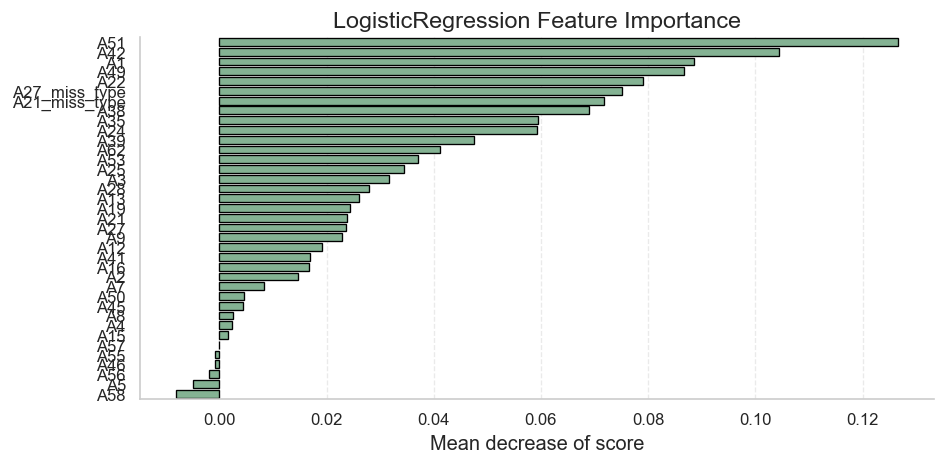

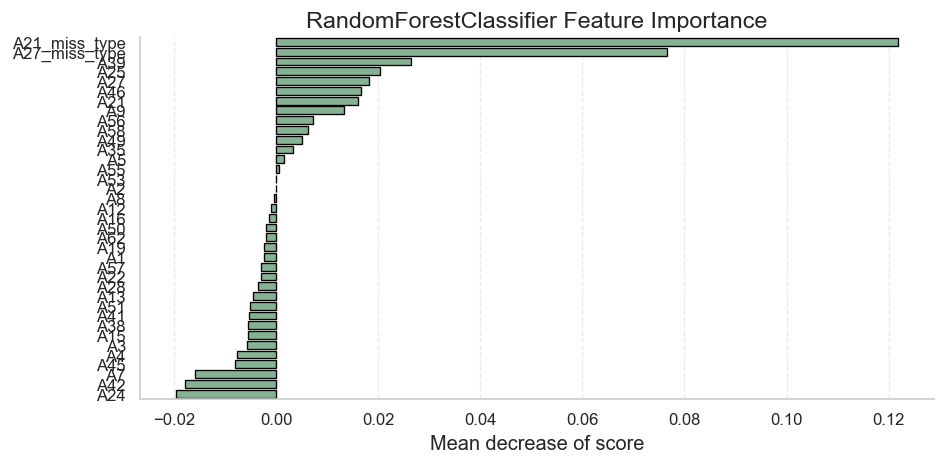

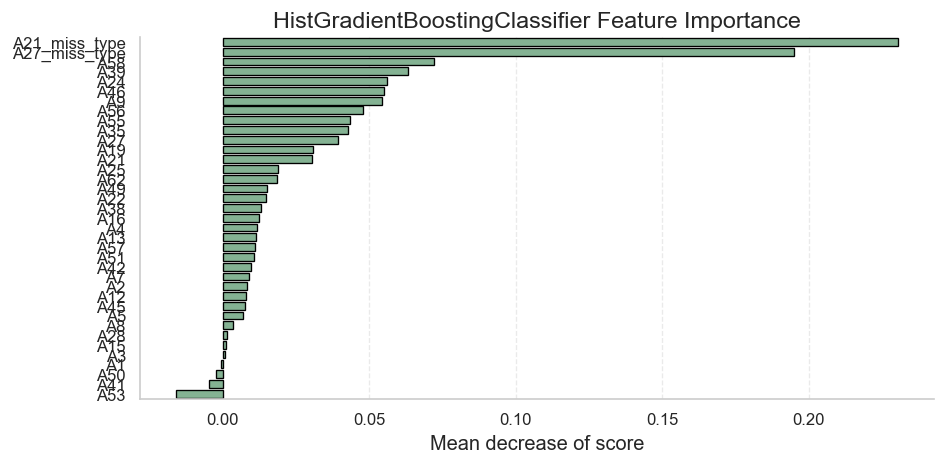

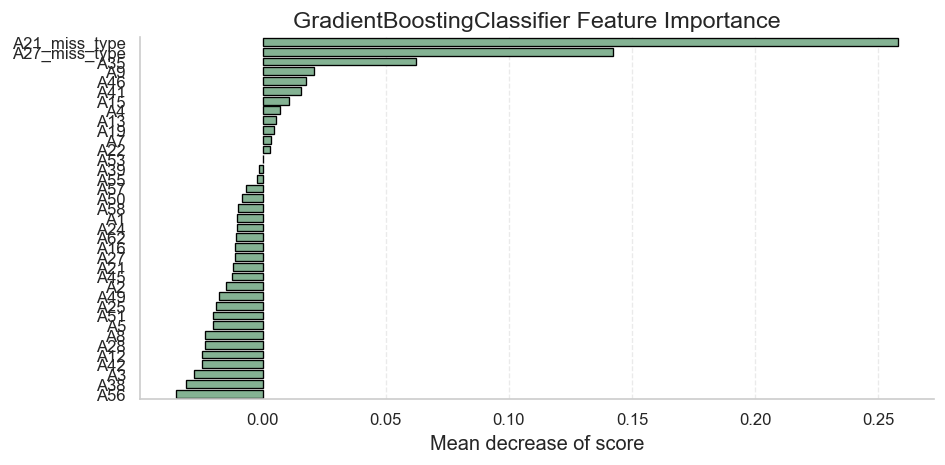

In [318]:
features = []
features_importances = []
for i in tuned_classifiers:
    a = plot_feature_importance(i[1], X_test_final, y_test, top_n=50)
    features_importances += list(a['Importance'])
    features += list(a['Feature'])

In [319]:
features_importances_df = pd.DataFrame(pd.DataFrame(data=features).T.sort_values(by=1).T.value_counts())
features_importances_df

,count
0,
A51,4
A42,4
A1,4
A49,4
A22,4
A27_miss_type,4
A21_miss_type,4
A38,4
A35,4


In [320]:
features_importances_df = pd.DataFrame(data=[features, features_importances]).T
features_importances_df.index = features_importances_df[0]
features_importances_df = features_importances_df.drop(columns=[0])
features_importances_df = features_importances_df.join(pd.DataFrame(pd.DataFrame(data=features).T.sort_values(by=1).T.value_counts()), on=0)
features_importances_df.groupby(level=0).mean().sort_values(by=1, ascending=False)

,1,count
0,,
A21_miss_type,0.170528,4.0
A27_miss_type,0.122299,4.0
A35,0.041881,4.0
A39,0.033965,4.0
A51,0.028075,4.0
A9,0.027776,4.0
A22,0.023376,4.0
A49,0.022327,4.0
A46,0.022052,4.0
